# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

How can a used car business optimize profit on used cars? In this study, our goal is to use regression techniques on vehicle features to identify which features affect the sales price of a used car. By analyzing the relationship between price and attributes like age, mileage, and brand, we can identify the key drivers of value and provide actionable recommendations to optimize pricing and inventory.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

The dataset contains approximately 426,000 used car listings with features such as price, year, manufacturer, model, condition, odometer, fuel type, transmission, and location. Initial exploration will focus on understanding data types, distributions, and potential data quality issues such as missing values, duplicates, and outliers.For example, extremely high or low prices, year of car less than 2000, mileage is greater than 300 miles.

We will also examine relationships between variables - price vs. age or mileage to identify early patterns that may influence modeling decisions.

STEPS TO ANALYZE DATA

STEP 1 Examine dataset structure (rows, columns, data types)
*   Load the dataset and inspect its shape
*   Display the first few rows (.head()) to understand what each column represents
*   Check data types using .info() to confirm numerical vs. categorical variables

In [61]:
# Load the dataset
import pandas as pd
vehicles = pd.read_csv('/content/data/vehicles.csv')
display(vehicles)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy


In [62]:
# Inspect its shape
vehicles.shape

# Result: 426,880 rows - individual car listings (data points), 18 columns - features/variables describing each car

(426880, 18)

In [63]:
# View the first few rows
vehicles.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [64]:
# Check column names
vehicles.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [65]:
# Check data types
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

STEP 2 Identify data quality issues (missing values, duplicates, invalid entries)

*   Check for missing values using .isnull().sum() and calculate percentages

*   Decide which columns have significant missing values that may need removal or filled in with the mode.

*   Check for duplicate rows using .duplicated() and remove them - none found.

*   Look for invalid or unrealistic values. For example, price ≤ 0, mileage extremely high, year in the future. Filter out these records during data cleaning step.

In [66]:
# Check for missing values
vehicles.isnull().sum().sort_values(ascending=False)
# drop

,0
size,306361
cylinders,177678
condition,174104
VIN,161042
drive,130567
paint_color,130203
type,92858
manufacturer,17646
title_status,8242
model,5277


In [67]:
# Missing values in percentage
(vehicles.isnull().mean() * 100).sort_values(ascending=False)


,0
size,71.767476
cylinders,41.622470
condition,40.785232
VIN,37.725356
drive,30.586347
paint_color,30.501078
type,21.752717
manufacturer,4.133714
title_status,1.930753
model,1.236179


**Analysis**

Drop these columns:

*   VIN (38%) - not useful for modeling
*   size (71%) - too much missing data

Keep these columns with missing values as they are valuable for price prediction:

*   cylinders (41%)
*   condition (39%)
*   drive (31%)
*   paint_color (30%)
*   type (22%)

In [69]:
# Identify duplicate rows - none
vehicles.duplicated().sum()

np.int64(0)

In [71]:
# Inspect and filter out unrealistic data - price is less than 0
vehicles[vehicles['price'] <= 0] # 32,895 rows price is less than 0


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
10,7218893038,el paso,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tx
11,7218325704,el paso,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tx
12,7217788283,el paso,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tx
13,7217147606,el paso,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tx
14,7209027818,el paso,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426764,7303347225,wyoming,0,2018.0,NaN,peterbilt 579,NaN,NaN,diesel,1.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,wy
426812,7302877815,wyoming,0,2006.0,toyota,scion tc,excellent,4 cylinders,gas,195000.0,clean,automatic,JTKDE177460109655,fwd,NaN,NaN,silver,wy
426832,7302353283,wyoming,0,2004.0,toyota,prius,excellent,4 cylinders,hybrid,239000.0,clean,automatic,JTDKB20U840108051,fwd,NaN,NaN,blue,wy
426836,7302301268,wyoming,0,2018.0,ram,2500,excellent,6 cylinders,diesel,20492.0,clean,automatic,3C6UR5HL3JG307217,4wd,full-size,truck,white,wy


In [72]:
# Inspect and filter out unrealistic data - odometer greater than 300,000 due to liability risk
vehicles[vehicles['odometer'] > 300000] #3032 rows

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
455,7314165149,birmingham,22500,1929.0,ford,NaN,NaN,NaN,gas,9999999.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,al
527,7313736542,birmingham,5500,2001.0,ford,e350 van,fair,NaN,diesel,340000.0,clean,automatic,NaN,fwd,NaN,van,white,al
562,7313478091,birmingham,27990,2014.0,ram,2500 4x4,like new,6 cylinders,diesel,2222222.0,clean,automatic,NaN,4wd,full-size,truck,white,al
615,7312878239,birmingham,0,2014.0,ram,2500 slt 4x4,like new,6 cylinders,diesel,1111111.0,clean,automatic,NaN,4wd,full-size,truck,white,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426306,7316451826,wyoming,4999,1999.0,ford,f350 crew cab,good,10 cylinders,gas,375400.0,clean,automatic,NaN,4wd,NaN,NaN,black,wy
426377,7313784096,wyoming,8600,2005.0,ford,f350,good,8 cylinders,diesel,305000.0,clean,automatic,NaN,4wd,full-size,truck,blue,wy
426449,7312145049,wyoming,5500,2013.0,ford,expedition el,NaN,NaN,gas,383000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,wy
426505,7311015199,wyoming,8995,2016.0,ford,expedition el,NaN,6 cylinders,gas,388000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,wy


In [73]:
# Inpsect and filter out unrealistic data - year greater than 2026 or less than year 2000
vehicles[vehicles['year'] > 2026] # no rows
vehicles[vehicles['year'] < 2000] # 25,250 rows


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
37,7316130053,auburn,4500,1992.0,jeep,cherokee,excellent,6 cylinders,gas,192000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,al
101,7309160821,auburn,12990,1968.0,volvo,NaN,NaN,NaN,gas,99999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
137,7305082143,auburn,2500,1966.0,NaN,1966 C-30 1 ton,good,6 cylinders,gas,47000.0,clean,manual,NaN,rwd,full-size,pickup,brown,al
185,7316853268,birmingham,1800,1998.0,toyota,rav4,good,4 cylinders,gas,240537.0,clean,manual,NaN,NaN,NaN,NaN,green,al
193,7316734951,birmingham,5900,1998.0,ford,f150,excellent,8 cylinders,gas,214000.0,clean,automatic,NaN,NaN,full-size,truck,red,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426813,7302839732,wyoming,1000,1998.0,ford,explorer,NaN,6 cylinders,gas,190000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,wy
426815,7302634053,wyoming,5000,1996.0,NaN,96 Suburban,excellent,8 cylinders,gas,170000.0,clean,automatic,NaN,NaN,NaN,SUV,brown,wy
426831,7302384818,wyoming,9800,1985.0,nissan,300zx coupe with t-tops,like new,6 cylinders,gas,115000.0,clean,automatic,NaN,rwd,sub-compact,hatchback,red,wy
426833,7302338378,wyoming,6800,1997.0,jaguar,xk8 convertible,good,8 cylinders,gas,69550.0,clean,automatic,SAJGX2749VCOO8376,rwd,compact,convertible,white,wy


In [74]:
# Inpsect and filter out unrealistic data - condition is salvage
vehicles[vehicles['condition'] == 'salvage'] # 601 rows


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
3326,7308530084,huntsville / decatur,800,2007.0,ford,freestyle,salvage,6 cylinders,gas,142862.0,clean,automatic,NaN,fwd,full-size,wagon,grey,al
5086,7316470951,anchorage / mat-su,2500,1999.0,chevrolet,k3500,salvage,8 cylinders,gas,178000.0,clean,automatic,1GCHK33R0XF081095,4wd,full-size,pickup,grey,ak
5262,7315604128,anchorage / mat-su,800,1986.0,ford,f-350 super duty,salvage,NaN,gas,200000.0,clean,automatic,NaN,4wd,full-size,truck,NaN,ak
5609,7314408746,anchorage / mat-su,1000,2000.0,jeep,cherokee classic,salvage,6 cylinders,gas,230000.0,clean,automatic,NaN,rwd,NaN,SUV,white,ak
5752,7313705602,anchorage / mat-su,15000,1964.0,ford,mustang,salvage,6 cylinders,gas,67000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,ak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425354,7312294553,sheboygan,1150,1987.0,NaN,1987 Bronco II,salvage,6 cylinders,gas,134584.0,clean,manual,NaN,4wd,mid-size,offroad,red,wi
425544,7317071710,wausau,700,1998.0,toyota,camry xle,salvage,6 cylinders,gas,321132.0,clean,automatic,NaN,fwd,compact,sedan,grey,wi
426106,7305894766,wausau,850,1987.0,ram,NaN,salvage,NaN,gas,9999999.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,wi
426170,7304251093,wausau,500,2004.0,pontiac,bonneville sle,salvage,6 cylinders,gas,195000.0,clean,automatic,NaN,fwd,NaN,NaN,red,wi


STEP 3 Analyze distribution of key variables, including price

*   Generate summary statistics using .describe()
*   Plot histograms or density plots for price to check skewness
*   Use boxplots to identify outliers in price and other numerical features






In [75]:
# Summary statistics
vehicles.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


<Axes: >

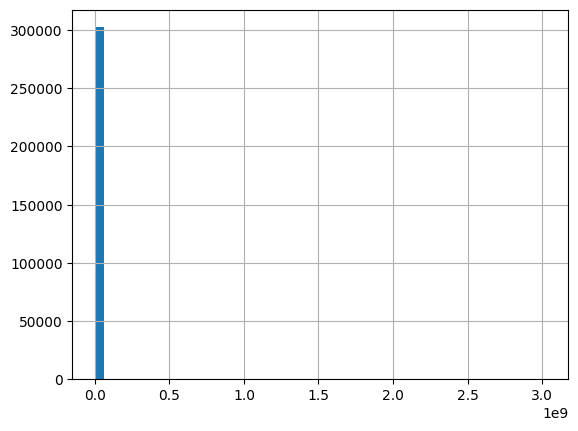

In [17]:
# Histogram of price

vehicles['price'].hist(bins=50)

<Axes: >

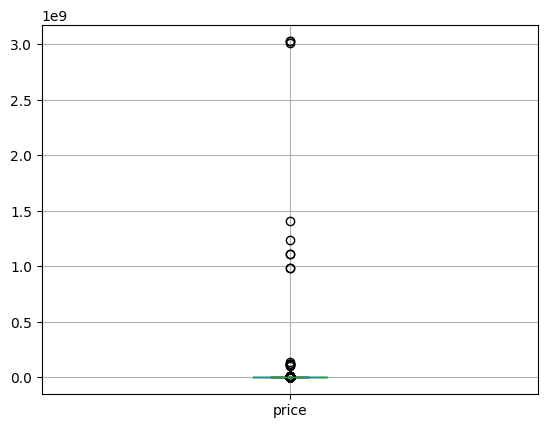

In [18]:
# Boxplot of outliers
vehicles.boxplot(column='price')

STEP 4 Explore relationships between features and price

*   Create scatter plots - price vs. mileage and price vs. year
*   Compute correlations for numerical variables (.corr())
*   Use boxplots to compare price across categorical variables - condition and fuel type
*   Identify which variables show strong or weak relationships with price

<Axes: xlabel='year', ylabel='price'>

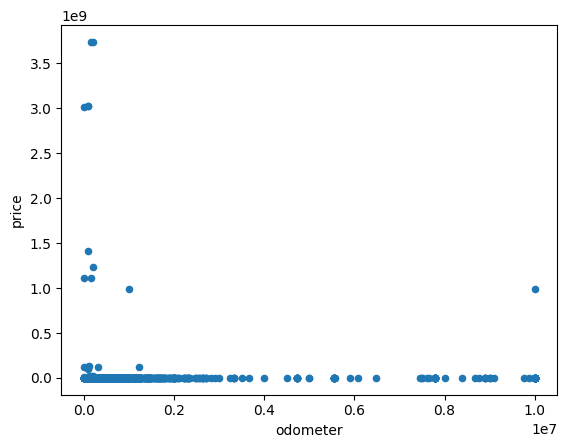

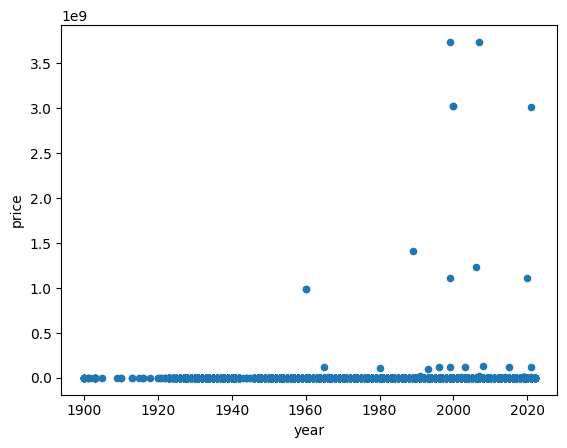

In [76]:
# Create scatter plots

vehicles.plot.scatter(x='odometer', y='price')
vehicles.plot.scatter(x='year', y='price')

In [20]:
# Correlation matrix

vehicles.corr(numeric_only=True)

,id,price,year,odometer
id,1.000000,-0.001316,-0.055613,0.007735
price,-0.001316,1.000000,-0.005848,0.014519
year,-0.055613,-0.005848,1.000000,-0.151368
odometer,0.007735,0.014519,-0.151368,1.000000


<Axes: title={'center': 'price'}, xlabel='condition'>

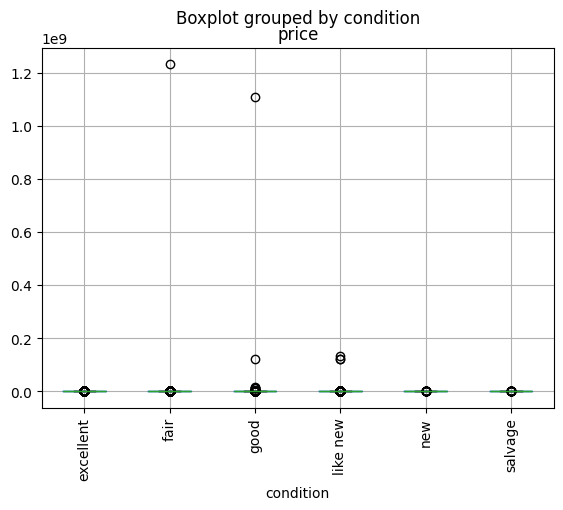

In [21]:
# Boxplot for categorical variables

vehicles.boxplot(column='price', by='condition', rot=90)

STEP 5 Review categorical variables for consistency and distribution
*   List unique values for each categorical column (.unique()) and check for inconsistent labels to standardize them at next step
*   Identify rare categories. Count frequencies using .value_counts() to understand common vs rare categories
*   Identify rare categories for grouping.








In [22]:
# List unique values for each categorical column (.unique())
# Unique values

# vehicles['fuel'].unique()
# vehicles['transmission'].unique()
# vehicles['condition'].unique()
# vehicles['drive'].unique()
# vehicles['type'].unique()
# vehicles['manufacturer'].unique()
# vehicles['model'].unique()
# vehicles['cylinders'].unique()
# vehicles['title_status'].unique()
# vehicles['paint_color'].unique()
# vehicles['state'].unique()
categorical_cols = [
    'fuel', 'transmission', 'condition', 'drive', 'type',
    'manufacturer', 'model', 'cylinders', 'title_status',
    'paint_color', 'state'
]

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(vehicles[col].unique())


Column: fuel
[nan 'gas' 'other' 'diesel' 'hybrid' 'electric']

Column: transmission
[nan 'other' 'automatic' 'manual']

Column: condition
[nan 'good' 'excellent' 'fair' 'like new' 'new' 'salvage']

Column: drive
[nan 'rwd' '4wd' 'fwd']

Column: type
[nan 'pickup' 'truck' 'other' 'coupe' 'SUV' 'hatchback' 'mini-van' 'sedan'
 'offroad' 'bus' 'van' 'convertible' 'wagon']

Column: manufacturer
[nan 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' 'acura' 'hyundai'
 'mercedes-benz' 'bmw' 'mitsubishi' 'volkswagen' 'porsche' 'kia' 'rover'
 'ferrari' 'mini' 'pontiac' 'fiat' 'tesla' 'saturn' 'mercury'
 'harley-davidson' 'datsun' 'aston-martin' 'land rover' 'morgan']

Column: model
[nan 'sierra 1500 crew cab slt' 'silverado 1500' ...
 'a3 2.0t premium cabriolet' '06 ranger' 'sevanna van']

Column: cylinders
[nan '8 cylinders' '6 cylinders' '4 cylinders' '5 cy

In [23]:
# Review frequency counts/distributions

# vehicles['fuel'].value_counts()
# vehicles['transmission'].value_counts()
# vehicles['condition'].value_counts()
# vehicles['drive'].value_counts()
# vehicles['type'].value_counts()
# vehicles['manufacturer'].value_counts()
# vehicles['model'].value_counts()
# vehicles['cylinders'].value_counts()
# vehicles['paint_color'].value_counts()
# vehicles['state'].value_counts()

cols = [
    'fuel', 'transmission', 'condition', 'drive', 'type',
    'manufacturer', 'model', 'cylinders', 'paint_color', 'state'
]

for col in cols:
    print(f"\nColumn: {col}")
    print(vehicles[col].value_counts())

# Summary of unique counts
vehicles[cols].nunique()


Column: fuel
fuel
gas         254660
other        22398
diesel       18454
hybrid        3833
electric      1282
Name: count, dtype: int64

Column: transmission
transmission
automatic    237527
other         45880
manual        17455
Name: count, dtype: int64

Column: condition
condition
good         88107
excellent    75071
like new     14706
fair          4881
new            928
salvage        446
Name: count, dtype: int64

Column: drive
drive
4wd    88525
fwd    76482
rwd    42075
Name: count, dtype: int64

Column: type
type
sedan          63836
SUV            53811
pickup         30376
truck          21331
other          16402
coupe          13969
hatchback      12090
wagon           7556
van             6077
convertible     5819
mini-van        3482
offroad          448
bus              351
Name: count, dtype: int64

Column: manufacturer
manufacturer
ford               48934
chevrolet          39180
toyota             24376
honda              15422
nissan             13503
jeep  

,0
fuel,5
transmission,3
condition,6
drive,3
type,13
manufacturer,42
model,23450
cylinders,8
paint_color,12
state,41


In [24]:
# Identify rare categories for grouping

col = 'type'

freq = vehicles[col].value_counts(normalize=True)  # percentage
rare = freq[freq < 0.01]  # less than 1%

print(rare)

type
offroad    0.001902
bus        0.001490
Name: proportion, dtype: float64


STEP 6 Assess dataset relevance to business objective
*   Evaluate whether key factors influencing price (e.g. age, mileage, brand, condition) are present
*   Identify any missing variables that could improve analysis (e.g., accident history)
*   Determine if the dataset size and feature set are sufficient for building a reliable pricing model
*   Form initial hypotheses about what drives price based on early exploration







In [25]:
# Evaluate key drivers of price
# Create vehicle age
vehicles['vehicle_age'] = 2026 - vehicles['year']

# Correlation with price
vehicles[['price', 'vehicle_age', 'odometer']].corr(numeric_only=True)

,price,vehicle_age,odometer
price,1.000000,0.005848,0.014519
vehicle_age,0.005848,1.000000,0.151368
odometer,0.014519,0.151368,1.000000


In [80]:
# Compare price across key categorical variables

# Condition
vehicles.groupby('condition')['price'].median().sort_values(ascending=False)

# Manufacturer (top 10 for readability)
vehicles.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(10)

# Type
vehicles.groupby('type')['price'].median().sort_values(ascending=False)

# Fuel
vehicles.groupby('fuel')['price'].median().sort_values(ascending=False)

,price
fuel,
diesel,27990.0
other,25990.0
electric,22544.5
gas,11998.0
hybrid,11995.0


In [81]:
# Check feature completeness for modeling
# Focus on key modeling features
key_features = ['price', 'year','cylinders', 'odometer', 'VIN', 'manufacturer', 'condition', 'fuel', 'transmission']

vehicles[key_features].isnull().mean() * 100

,0
price,0.000000
year,0.282281
cylinders,41.622470
odometer,1.030735
VIN,37.725356
manufacturer,4.133714
condition,40.785232
fuel,0.705819
transmission,0.598763


In [28]:
# Does price decrease with mileage?
vehicles[['price', 'odometer']].corr()

,price,odometer
price,1.000000,0.014519
odometer,0.014519,1.000000


In [29]:
# Does price increase with newer cars?
vehicles[['price', 'vehicle_age']].corr()

,price,vehicle_age
price,1.000000,0.005848
vehicle_age,0.005848,1.000000


**Analysis**

The dataset contains key variables relevant to determining used car prices, including vehicle age (derived from year), odometer, manufacturer, model, condition and vehicle type. These features align well with factors that consumers typically consider when evaluating used cars.

However, some important variables which can influence price are not included, such as accident history, maintenance records, number of previous owners, and trim. The absence of these variables may limit the ability to fully capture all drivers of price. Overall, the dataset is sufficient and contains relevant features to support a reliable analysis and predictive modeling of used car prices, despite some missing contextual variables.

Preliminary exploration suggests that newer vehicles (lower vehicle age), lower mileage, better condition, and certain manufacturers are associated with higher prices. Additionally, vehicle type (SUVs and trucks) may influence pricing patterns.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [91]:
# Data Preparation

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [92]:
# Make a back up copy and a working copy so original dataset is preserved
vehicles_backup = vehicles.copy()
# Working copy
df = vehicles.copy()

In [93]:
# Drop columns that are not useful or have too many missing values
df = df.drop(columns=['VIN', 'size'], errors='ignore')

In [94]:
# Remove invalid or unrealistic values
df = df[
    (df['price'] > 0) & (df['price'] <= 100000) &
    (df['year'] >= 2000) & (df['year'] <= 2026) &
    (df['odometer'] >= 0) & (df['odometer'] <= 300000) &
    (df['condition'] != 'salvage')
]

In [95]:
# Feature engineering: create vehicle age
df['vehicle_age'] = 2026 - df['year']

In [102]:
# Log-transform price because price is right-skewed - many cars have lower prices and fewer cars have high prices
df['log_price'] = np.log(df['price'])

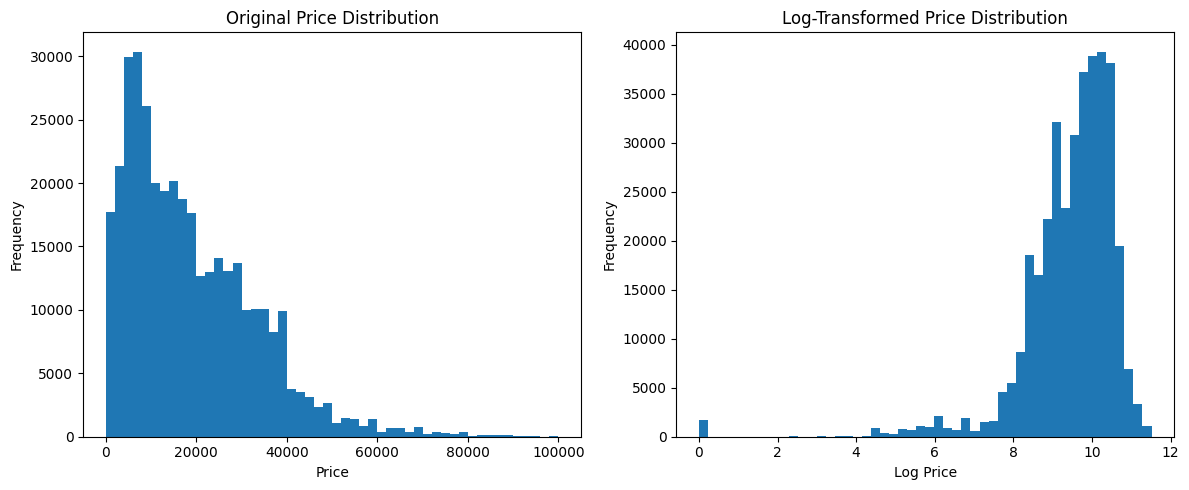

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Filter out non-finite values from log_price before plotting
# Create log_price_finite to remove non-finite values in the log price column - replace with NaN or drop

log_price_finite = df['log_price'].replace([-np.inf, np.inf], np.nan).dropna()

# Plot side-by-side
plt.figure(figsize=(12,5))

# Original price - left
plt.subplot(1,2,1)
plt.hist(df['price'], bins=50)
plt.title("Original Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

# Log-transformed price - right
plt.subplot(1,2,2)
plt.hist(log_price_finite, bins=50) # Use the filtered log_price
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [103]:
# Standardize categorical text formatting
categorical_cols = [
    'manufacturer', 'model', 'condition', 'cylinders',
    'fuel', 'title_status', 'transmission', 'drive',
    'type', 'paint_color', 'state'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()
        df[col] = df[col].replace('nan', np.nan)

In [104]:
# Group rare vehicle types
if 'type' in df.columns:
    df['type'] = df['type'].replace({
        'suv': 'suv',
        'mini-van': 'van',
        'pickup': 'truck'
    })

In [108]:
# Identify numeric and categorical features
numeric_features = ['vehicle_age', 'odometer']

categorical_features = [
    col for col in features
    if col not in numeric_features
]

In [112]:
# convert condition to numeric

condition_map = {
    'salvage': 0,
    'fair': 1,
    'good': 2,
    'excellent': 3,
    'like new': 4,
    'new': 5
}

df['condition_num'] = df['condition'].map(condition_map)
df['condition_num']

,condition_num
27,2.0
28,2.0
29,2.0
30,2.0
31,3.0
...,...
426875,2.0
426876,2.0
426877,2.0
426878,2.0


In [115]:
# convert cylinders to numeric

df['cylinders_num'] = df['cylinders'].str.extract('(\d+)').astype(float)

df['cylinders_num']

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9369/2971861118.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['cylinders_num'] = df['cylinders'].str.extract('(\d+)').astype(float)


,cylinders_num
27,8.0
28,8.0
29,8.0
30,8.0
31,6.0
...,...
426875,6.0
426876,NaN
426877,NaN
426878,6.0


In [133]:
# Select features for modeling
features = [
    'vehicle_age', 'odometer',
    'manufacturer', 'model', 'condition_num', 'cylinders_num',
    'fuel', 'title_status', 'transmission', 'drive',
    'type', 'paint_color', 'state'
]

features = [col for col in features if col in df.columns]

X = df[features]
y = df['log_price']

# Define types
numeric_features = [
    'vehicle_age', 'odometer', 'condition_num', 'cylinders_num'
]

categorical_features = [
    'manufacturer', 'model', 'fuel', 'title_status',
    'transmission', 'drive', 'type', 'paint_color', 'state'
]

In [134]:
# Numeric pipeline: Replace missing values with the median of column and scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [121]:
# Categorical pipeline: Fill missing values with unknown and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [136]:
# Build preprocessor, combine preprocessing steps, scale all numbers, turn categorical features into numerical format
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [137]:
# Train-test split before modeling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [139]:
print(X_train.columns.tolist())

['vehicle_age', 'odometer', 'manufacturer', 'model', 'condition_num', 'cylinders_num', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


In [138]:
# Fit preprocessing only on training data
X_train_prepared = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_prepared = preprocessor.transform(X_test)

In [140]:
# Check final shapes before modeling
print("X_train shape:", X_train_prepared.shape)
print("X_test shape:", X_test_prepared.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (290358, 20311)
X_test shape: (72590, 20311)
y_train shape: (290358,)
y_test shape: (72590,)


In [141]:
import numpy as np
# Convert the sparse matrix to a dense array before checking for NaNs
# Note: After filling, there should ideally be no NaNs.
if hasattr(X_train_prepared, 'toarray'):
    print(np.isnan(X_train_prepared.toarray()).sum())
else:
    print(np.isnan(X_train_prepared).sum())

0


**Comment**

In the data preparation phase, invalid and unrealistic records were removed, including negative prices, unrealistic model years, extreme mileage values (greater than 300,000 miles or less than 0 miles), and unusually high prices. Columns with limited predictive value or excessive missingness, such as VIN and size (71% of data missing), were dropped. A new feature, vehicle age, was engineered from the year column. Because price is often skewed, a log transformation was applied to create the target variable. Categorical variables were standardized, missing values were handled by filling with the median value, and categorical features were one-hot encoded for modeling with sklearn. Numeric variables were filled and scaled before splitting the data into training and testing sets.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

For Modeling, test Linear Regression, Ridge and Lasso.

In [142]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [158]:
# Linear Regression
# Create pipeline with preprocessing + model
from sklearn.pipeline import Pipeline

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Cross-validation
lr_scores = cross_val_score(
    lr_model, X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("Linear Regression RMSE:", -lr_scores.mean())

Linear Regression RMSE: 0.9297504580469754


In [164]:
# converts the error back to the original price scale

import numpy as np
np.exp(0.9297504580469754)

np.float64(2.533876790154596)

In [151]:
# Ridge Regression (with tuning)
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid_ridge = {
    'model__alpha': [0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_grid.fit(X_train, y_train)

print("Ridge alpha:", ridge_grid.best_params_)
print("Ridge RMSE:", -ridge_grid.best_score_)

Ridge alpha: {'model__alpha': 1}
Ridge RMSE: 0.9267826093608995


In [165]:
# converts the error back to the original price scale
import numpy as np
np.exp(0.9267826093608995)

np.float64(2.5263677755734815)

In [163]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

param_grid_lasso = {
    'model__alpha': [0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso_model,
    param_grid_lasso,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Lasso alpha:", lasso_grid.best_params_)
print("Lasso RMSE:", -lasso_grid.best_score_)

Lasso alpha: {'model__alpha': 0.01}
Lasso RMSE: 1.0255038269749723


In [166]:
# converts the error back to the original price scale
import numpy as np
np.exp(1.0255038269749723)

np.float64(2.7885000282405366)

**Modeling Results**

*   Linear Regression RMSE: 0.9297504580469754, np.float64(2.533876790154596)
*   Ridge RMSE: 0.9267826093608995, np.float64(2.5263677755734815)
*   Lasso RMSE: 1.0255038269749723, np.float64(2.7885000282405366





**Summary**

Multiple regression models, including Linear Regression, Ridge, and Lasso—were developed to predict used car prices. Cross-validation was used to evaluate model performance, with RMSE as the primary metric. Among the models, Ridge Regression performed best, achieving the lowest RMSE and slightly outperforming Linear Regression and producing more accurate results Lasso. This corresponds to predictions being within approximately two times the actual price. Lasso performed worse, likely due to removing useful features. Ridge Regression was selected as the final model due to its superior performance and ability to handle high-dimensional data.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Feature Importance Analysis**

Analysis of model coefficients from the Ridge Regression model shows that certain features significantly influence vehicle prices. Higher prices are associated with luxury brands, specialty vehicles, and certain truck or SUV models, while lower prices are associated with older vehicles, higher mileage, and lower condition ratings. Although some highly specific model-level features show strong effects, broader patterns such as brand, vehicle type, and condition provide more actionable insights for business decisions.

In [58]:
# Which features increase, decrease price??

best_model = ridge_grid.best_estimator_
feature_names = preprocessor.get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_

import pandas as pd

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df.sort_values(by='coefficient', ascending=False).head(20)

,feature,coefficient
5908,cat__model_excursion 4x4 limited 6.8l v10 gas ...,3.231632
13835,cat__model_srt10,2.925915
13969,cat__model_super duty,2.904234
5209,cat__model_e-series chassis e 350 sd,2.901268
15362,cat__model_viper convertible,2.715382
6413,cat__model_f-250 4x4 6.8l v10 triton g,2.703337
6656,cat__model_f-650 sd,2.601764
6606,cat__model_f-450 4x2 truck w/new crysteel 11' ...,2.570325
15361,cat__model_viper,2.521716
8349,cat__model_gulf independence,2.369946


Analysis of model coefficients shows that certain vehicle models and brands significantly increase price, particularly luxury brands (yes, Ferrari :)), specialty vehicles like campers, and commercial trucks like Freightliner and International. These results indicate that both brand reputation and vehicle type play a major role in pricing. However, some very specific model categories appear to add noise and make the results harder to interpret. Overall, broader patterns—such as vehicle type, brand, and condition provide more actionable insights for pricing decisions.

Ridge Regression was identified as the best-performing model, achieving the lowest RMSE among the models tested. Predictions are generally within approximately 2× the actual price, indicating that the model captures overall pricing trends but is less precise for exact values. Key drivers of price include vehicle age, mileage, condition, brand, and vehicle type. While the model provides useful guidance for pricing and inventory decisions, its accuracy is limited by missing variables such as accident history and trim details, as well as highly granular categories. Overall, the model meets the business objective by delivering actionable insights, even though precise price prediction remains challenging.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

**Used Car Pricing Evaluation**

This analysis provides actionable insights into the factors that influence used car prices and offers guidance to help dealerships optimize inventory and pricing strategies.

The results show that vehicle age, mileage, condition, brand, and vehicle type are the primary drivers of price. Newer vehicles with lower mileage and better condition consistently command higher prices. Additionally, certain brands—particularly those with strong reputations or luxury positioning—tend to retain higher value. Vehicle type also plays an important role, with SUVs and trucks generally achieving higher resale prices compared to smaller vehicles.

The analysis shows that the following factors have the strongest impact on vehicle prices:


*   Vehicle Age Newer cars consistently command higher prices.
*   Odometer/Lower mileage significantly increases value.
*   Condition Vehicles in better condition sell for higher prices.
*   Brand & Model Certain brands - luxury or high-reputation manufacturers command higher prices.
*   Vehicle Type SUVs, trucks, and specialty vehicles tend to have higher resale values than smaller cars.

Multiple models were tested to predict price: Linear Regression, Ridge Regression and Lasso Regression. Ridge Regression performed best, providing the most reliable overall pricing trends. While the model captures overall pricing trends effectively, predictions can vary by approximately two times the actual price and should be used as a decision-support tool rather than an exact pricing mechanism.

From a business perspective, dealerships should prioritize stocking newer, low-mileage vehicles from high-demand brands, with a focus on SUVs and trucks. Outliers such as vehicles with salvage condition, vehicles with very high-mileage (over 300,000 miles), or very old vehicles (year earlier than 2000) were removed, as these introduce pricing uncertainty and are more difficult to model accurately.

I suggest incorporating additional data—such as accident history, maintenance records, and vehicle features to significantly improve vehicle pricing accuracy. With the given data, the current model provides valuable high-level insights that can help guide inventory selection and pricing strategy.